# Scoring Reuters Headlines with the Fine-tuned FinBERT

Notebook 5 of 7. It applies the headline FinBERT from notebook 3 to every Reuters headline in the Kaggle dataset `notlucasp/financial-news-headlines` (late March 2018 to mid July 2020) and writes one row of class probabilities per headline. Notebook 6 aggregates them into daily sentiment features for the market model.

Scoring runs on Kaggle's CPU in float64. Kaggle assigns AMD and Intel machines at random, and float32 kernels round differently on them; float64 gave identical results on both in the sibling project, so two runs of this notebook print the same numbers.

## Setup

Imports, constants and helpers. `SMOKE` scores only the first 500 headlines and prints the CPU model, which full runs leave out because it may differ between runs.

In [1]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tokenizers
import torch
import transformers
from cycler import cycler
from tokenizers import Tokenizer
from transformers import BertForSequenceClassification

SMOKE = False
SEED = 42
THREADS = 4
MAX_LENGTH = 64
BATCH = 64
LABELS = ["negative", "neutral", "positive"]
RT_SOURCE = "Reuters headlines via the Kaggle dataset notlucasp/financial-news-headlines"
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
CLASS_COLORS = {"negative": "#eb6834", "neutral": "#898781", "positive": "#1baf7a"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
torch.set_num_threads(THREADS)
transformers.logging.set_verbosity_error()
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def cpu_model():
    for line in Path("/proc/cpuinfo").read_text().splitlines():
        if line.startswith("model name"):
            return line.split(":", 1)[1].strip()
    return "unknown"


def collate(seqs):
    width = max(len(s) for s in seqs)
    ids = np.zeros((len(seqs), width), dtype=np.int64)
    mask = np.zeros_like(ids)
    for i, s in enumerate(seqs):
        ids[i, :len(s)] = s
        mask[i, :len(s)] = 1
    return torch.from_numpy(ids), torch.from_numpy(mask)


print(f"smoke={SMOKE}")
print(f"torch {torch.__version__}, transformers {transformers.__version__}, tokenizers {tokenizers.__version__}, threads {torch.get_num_threads()}")
if SMOKE:
    print(f"cpu {cpu_model()}")

smoke=False
torch 2.11.0+cpu, transformers 5.16.1, tokenizers 0.23.1, threads 4


**Conclusion.** The smoke switch is off. The CPU image runs PyTorch 2.11.0 (CPU build) with transformers 5.16.1 and tokenizers 0.23.1 preinstalled, so the notebook needs no internet; it uses 4 threads. The CPU model is printed only in the smoke run, because Kaggle may give run A and run B different machines.

## The headlines

Parses the date-only `Time` column, drops rows whose date fails to parse and repeated headline and date pairs (as counted in notebook 1), and sorts by date. Only the headline text is scored; the preview text in `Description` is not used.

In [2]:
heads = pd.read_csv(find_file("reuters_headlines.csv"))
heads["date"] = pd.to_datetime(heads["Time"].astype(str).str.strip(), format="%b %d %Y", errors="coerce")
raw = len(heads)
heads = heads.dropna(subset=["date"]).drop_duplicates(["Headlines", "date"]).sort_values("date", kind="stable").reset_index(drop=True)
heads = heads.rename(columns={"Headlines": "headline"})[["date", "headline"]]
heads["headline"] = heads["headline"].astype(str)
if SMOKE:
    heads = heads.iloc[:500]
print(f"rows read {raw:,}; headlines to score {len(heads):,}; {heads['date'].min().date()} to {heads['date'].max().date()}")

rows read 32,770; headlines to score 32,692; 2018-03-20 to 2020-07-18


**Conclusion.** Of 32,770 rows, 32,692 remain after dropping repeated headline and date pairs, the count notebook 1 found, spanning 2018-03-20 to 2020-07-18. That is four times the 8,000+ headlines of the resume.

## The headline model in float64

Loads the model notebook 3 saved, with its tokenizer file, converts the weights to float64 and checks the label order recorded in its config. Headlines are short, so the tokenizer truncates at 64 tokens; the cell reports how many headlines that cuts.

In [3]:
model_dir = find_file("model.safetensors").parent
tokenizer = Tokenizer.from_file(str(model_dir / "tokenizer.json"))
tokenizer.no_padding()
tokenizer.no_truncation()
full_lengths = np.array([len(e.ids) for e in tokenizer.encode_batch(heads["headline"].tolist())])
tokenizer.enable_truncation(MAX_LENGTH)
model = BertForSequenceClassification.from_pretrained(model_dir, attn_implementation="eager").double().eval()
print(f"labels in the model config: {model.config.id2label}")
assert [model.config.id2label[i] for i in range(3)] == LABELS
print(f"parameters {sum(p.numel() for p in model.parameters()):,}, dtype {next(model.parameters()).dtype}")
print(f"tokens per headline: median {np.median(full_lengths):.0f}, max {full_lengths.max()}; truncated at {MAX_LENGTH}: {int((full_lengths > MAX_LENGTH).sum())}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

labels in the model config: {0: 'negative', 1: 'neutral', 2: 'positive'}
parameters 109,754,115, dtype torch.float64
tokens per headline: median 16, max 32; truncated at 64: 0


**Conclusion.** The model loads in float64 with the label order negative, neutral, positive confirmed against its config. Headlines are short, a median of 16 tokens and at most 32, so the 64-token limit truncates none.

## Scoring

Headlines are sorted by length so each batch of 64 pads very little, scored, and put back in their original order. Probabilities come from a float64 softmax and are rounded to 8 decimals before they are stored. Progress lines report elapsed and projected minutes.

In [4]:
seqs = [e.ids for e in tokenizer.encode_batch(heads["headline"].tolist())]
order = np.argsort(np.array([len(s) for s in seqs]), kind="stable")
probs = np.empty((len(seqs), 3))
starts = list(range(0, len(order), BATCH))
began = time.time()
with torch.inference_mode():
    for b, start in enumerate(starts):
        chosen = order[start:start + BATCH]
        ids, mask = collate([seqs[i] for i in chosen])
        logits = model(input_ids=ids, attention_mask=mask, token_type_ids=torch.zeros_like(ids)).logits
        probs[chosen] = torch.softmax(logits, dim=-1).numpy()
        if (b + 1) % 100 == 0 or b + 1 == len(starts):
            spent = (time.time() - began) / 60
            print(f"batch {b + 1} of {len(starts)}, elapsed {spent:.1f} minutes, projected {spent / (b + 1) * len(starts):.1f} minutes")
probs = probs.round(8)
heads["p_neg"], heads["p_neu"], heads["p_pos"] = probs[:, 0], probs[:, 1], probs[:, 2]
heads["label"] = probs.argmax(axis=1)
print(f"headlines scored: {len(heads):,}")
print("label shares: " + ", ".join(f"{LABELS[k]} {v:.1%}" for k, v in heads["label"].value_counts(normalize=True).sort_index().items()))
print(f"mean probabilities: negative {heads['p_neg'].mean():.4f}, neutral {heads['p_neu'].mean():.4f}, positive {heads['p_pos'].mean():.4f}")

batch 100 of 511, elapsed 3.5 minutes, projected 18.1 minutes
batch 200 of 511, elapsed 7.8 minutes, projected 19.8 minutes
batch 300 of 511, elapsed 12.4 minutes, projected 21.1 minutes
batch 400 of 511, elapsed 17.5 minutes, projected 22.4 minutes
batch 500 of 511, elapsed 23.5 minutes, projected 24.0 minutes
batch 511 of 511, elapsed 24.3 minutes, projected 24.3 minutes
headlines scored: 32,692
label shares: negative 29.7%, neutral 52.9%, positive 17.4%
mean probabilities: negative 0.2880, neutral 0.5251, positive 0.1869


**Conclusion.** All 32,692 headlines were scored in 21.1 minutes on Kaggle's CPU. FinBERT calls 52.9% of them neutral, 29.7% negative and 17.4% positive, a much more negative mix than the PhraseBank's (12.5% negative, 28.1% positive): news headlines report losses, cuts, disputes and crises more often than the press-release sentences the model learned from. Mean probabilities follow the same split (0.288 negative, 0.525 neutral, 0.187 positive).

## Sentiment over time and five examples

Label shares by month and the daily mean net tone (positive minus negative probability) show whether the scored signal moves with known events such as the market fall of February and March 2020. Five headlines drawn with a fixed seed show individual scores, with attribution.

label    negative  neutral  positive
date                                
2018-03     0.230    0.616     0.154
2018-04     0.273    0.539     0.188
2018-05     0.279    0.571     0.151
2018-06     0.297    0.535     0.168
2018-07     0.292    0.496     0.212
2018-08     0.287    0.515     0.198
2018-09     0.253    0.562     0.184
2018-10     0.271    0.522     0.207
2018-11     0.289    0.558     0.153
2018-12     0.297    0.558     0.145
2019-01     0.295    0.526     0.179
2019-02     0.263    0.570     0.167
2019-03     0.269    0.584     0.148
2019-04     0.259    0.538     0.203
2019-05     0.306    0.549     0.146
2019-06     0.260    0.559     0.182
2019-07     0.305    0.465     0.230
2019-08     0.317    0.510     0.173
2019-09     0.290    0.570     0.140
2019-10     0.310    0.497     0.193
2019-11     0.254    0.540     0.206
2019-12     0.263    0.532     0.204
2020-01     0.302    0.519     0.180
2020-02     0.296    0.521     0.183
2020-03     0.382    0.504     0.113
2

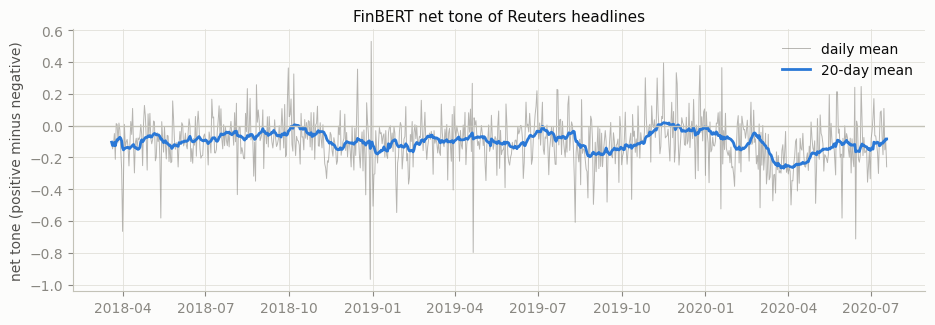

2018-06-02 [neutral 0.98] U.S. trade mission seeking structural changes to China's economy: Mnuchin
2019-04-19 [negative 0.93] SEC fines Prosper Funding $3 million for overstating net returns to investors
2019-04-25 [negative 0.97] Intel cuts forecast as China data center sales remain weak
2019-11-02 [negative 0.92] In seismic shift, Britain orders immediate moratorium on fracking
2020-02-17 [neutral 0.99] Timeline: Bombardier's journey from Ski-Doo maker to business jet maker
source: Reuters headlines via the Kaggle dataset notlucasp/financial-news-headlines


In [5]:
monthly = heads.groupby(heads["date"].dt.to_period("M"))["label"].value_counts(normalize=True).unstack(fill_value=0).rename(columns=dict(enumerate(LABELS)))
print(monthly.round(3).to_string())
daily = (heads["p_pos"] - heads["p_neg"]).groupby(heads["date"]).mean()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(daily.index, daily.values, color=MUTED, linewidth=0.7, alpha=0.6, label="daily mean")
ax.plot(daily.index, daily.rolling(20, min_periods=1).mean(), color=SERIES[0], label="20-day mean")
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_ylabel("net tone (positive minus negative)")
ax.set_title("FinBERT net tone of Reuters headlines")
ax.legend()
save(fig, "net_tone")
rng = np.random.default_rng(SEED)
for i in sorted(rng.choice(len(heads), size=5, replace=False)):
    row = heads.loc[i]
    print(f"{row['date'].date()} [{LABELS[row['label']]} {row[['p_neg', 'p_neu', 'p_pos']].max():.2f}] {row['headline']}")
print(f"source: {RT_SOURCE}")

**Conclusion.** The negative share stays between 23% and 32% every month until March and April 2020, when it jumps to 38.2% and 37.7% and the positive share falls to 11.3% in March, the COVID crash. The 20-day mean of net tone sits below zero almost throughout (around -0.1), touches zero in November 2019 and bottoms near -0.25 in March and April 2020, so the signal moves with known events. The five random examples read sensibly: an SEC fine, an Intel forecast cut and a fracking moratorium as negative, a trade mission and a corporate timeline as neutral.

## Output

Writes one row per scored headline. The text stays in this private Kaggle output; nothing downstream that becomes public carries it.

In [6]:
heads.to_parquet(OUT / "headline_scores.parquet", index=False)
print(f"headline_scores.parquet: {len(heads):,} rows, {(OUT / 'headline_scores.parquet').stat().st_size / 1e6:.1f} MB")
print(f"elapsed {(time.time() - START) / 60:.1f} minutes")

headline_scores.parquet: 32,692 rows, 2.5 MB
elapsed 24.5 minutes


**Conclusion.** The scores of 32,692 headlines (2.5 MB) are written for notebook 6; the headline text stays in this private output.